In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

import snappy

import ast
import numpy as np

from graph_utils import draw_one_graph

/Users/cretuluca/uni/licenta/.venv/lib/python3.11/site-packages/plink/gui.py:33: UserWarning: Plink failed to import tkinter, GUI will not be available
  warnings.warn('Plink failed to import tkinter, GUI will not be available')


In [3]:
def fix_pd_notation(pd_notation):
    pd_notation = pd_notation.replace(';', ',')
    return pd_notation

In [4]:
def filter_knot_info(knots_df: pd.DataFrame):
    relevant_attributes = ['Name', 'PD Notation', 'Unknotting Number', 'Crossing Number', 'Signature', 'Determinant', 
        'Double Slice Genus', 'Ozsvath-Szabo <i>tau</i>', 'Rasmussen <i>s</i>', 'Jones', 'Alexander'
    ]

    filtered_df = knots_df[relevant_attributes]
    filtered_df['PD Notation'] = filtered_df['PD Notation'].apply(fix_pd_notation)
    
    return filtered_df

In [5]:
knots_df = pd.read_csv('./knotinfo.csv')
print(knots_df.shape)

f_knots_df = filter_knot_info(knots_df)
f_knots_df.head()

f_knots_df['PD Notation']

(6900, 102)


0                         [[1,5,2,4],[3,1,4,6],[5,3,6,2]]
1               [[4,2,5,1],[8,6,1,5],[6,3,7,4],[2,7,3,8]]
2       [[2,8,3,7],[4,10,5,9],[6,2,7,1],[8,4,9,3],[10,...
3       [[1,5,2,4],[3,9,4,8],[5,1,6,10],[7,3,8,2],[9,7...
4       [[1,7,2,6],[3,10,4,11],[5,3,6,2],[7,1,8,12],[9...
                              ...                        
6895    [[5, 1, 6, 26], [1, 11, 2, 10], [11, 3, 12, 2]...
6896    [[5, 1, 6, 26], [1, 13, 2, 12], [11, 3, 12, 2]...
6897    [[5, 1, 6, 26], [1, 20, 2, 21], [11, 2, 12, 3]...
6898    [[5, 1, 6, 26], [1, 20, 2, 21], [11, 2, 12, 3]...
6899    [[5, 1, 6, 26], [1, 18, 2, 19], [11, 2, 12, 3]...
Name: PD Notation, Length: 6900, dtype: str

In [6]:
def pd_to_graph(pd_notation):
    pd_list = ast.literal_eval(pd_notation)
    knot = snappy.Link(pd_list)

    G = nx.Graph(knot.dual_graph().to_networkx())
    G = nx.convert_node_labels_to_integers(G)

    edges = list(G.edges())

    sources, targets = np.array([e[0] for e in edges]), np.array([e[1] for e in edges])
    return sources, targets


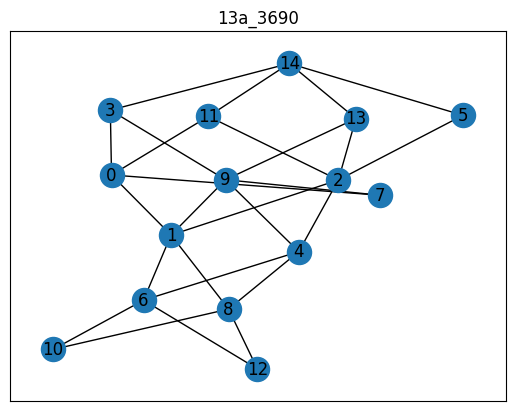

In [7]:
fig, ax = plt.subplots()
knot = 6666
draw_one_graph(ax, pd_to_graph(f_knots_df['PD Notation'][knot]), layout=nx.nx_agraph.graphviz_layout)
ax.set_title(f_knots_df['Name'][knot])

plt.show()

In [ ]:
from torch_geometric.loader import DataLoader

from knot_dataset import KnotDataset
from knot_model import KnotGNN
from training_utils import run_exp_pyg

train_ds = KnotDataset(".", split="train")
val_ds = KnotDataset(".", split="val")
test_ds = KnotDataset(".", split="test")
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

/Users/cretuluca/uni/licenta/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KnotDataset(train): y normalized (mean ~0, std ~1). Train stats: mean=[12.398550987243652], std=[0.8769583106040955]
KnotDataset(val): y normalized (mean ~0, std ~1). Train stats: mean=[12.398550987243652], std=[0.8769583106040955]
KnotDataset(test): y normalized (mean ~0, std ~1). Train stats: mean=[12.398550987243652], std=[0.8769583106040955]


In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = KnotGNN(hidden_dim=32, num_layers=2)
loss_fct = torch.nn.MSELoss()
run_exp_pyg(model, train_loader, val_loader, test_loader, loss_fct, lr=1e-3, num_epochs=500, device=device)



Model architecture:
KnotGNN(
  (convs): ModuleList(
    (0-1): 2 x GCNConv(32, 32)
  )
  (mlp): Sequential(
    (0): Linear(in_features=32, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

Start training:
[Epoch 1] train loss: 0.356 val loss: 1.190
[Epoch 2] train loss: 0.808 val loss: 1.191
[Epoch 3] train loss: 0.972 val loss: 1.190
[Epoch 4] train loss: 2.111 val loss: 1.189
[Epoch 5] train loss: 0.922 val loss: 1.190
[Epoch 6] train loss: 2.743 val loss: 1.189
[Epoch 7] train loss: 1.086 val loss: 1.190
[Epoch 8] train loss: 0.941 val loss: 1.190
[Epoch 9] train loss: 0.513 val loss: 1.191
[Epoch 10] train loss: 0.393 val loss: 1.189
[Epoch 11] train loss: 0.522 val loss: 1.189
[Epoch 12] train loss: 0.667 val loss: 1.189
[Epoch 13] train loss: 0.794 val loss: 1.191
[Epoch 14] train loss: 2.918 val loss: 1.189
[Epoch 15] train loss: 1.895 val loss: 1.189
[Epoch 16] train loss: 1.171 val loss: 1.190
[Epoch 17] train loss:

[{'train_loss': 1.01116987414982, 'val_loss': 1.194252279875935, 'epoch': 0},
 {'train_loss': 0.3556055426597595,
  'val_loss': 1.1896661250487617,
  'epoch': 1},
 {'train_loss': 0.8079373240470886, 'val_loss': 1.191129980571028, 'epoch': 2},
 {'train_loss': 0.9721004962921143,
  'val_loss': 1.1895435955213465,
  'epoch': 3},
 {'train_loss': 2.1105926036834717, 'val_loss': 1.188682038196619, 'epoch': 4},
 {'train_loss': 0.922499418258667, 'val_loss': 1.1896678039993065, 'epoch': 5},
 {'train_loss': 2.7431774139404297, 'val_loss': 1.189472382310508, 'epoch': 6},
 {'train_loss': 1.0857510566711426,
  'val_loss': 1.1896931492764018,
  'epoch': 7},
 {'train_loss': 0.9408389329910278, 'val_loss': 1.190282452624777, 'epoch': 8},
 {'train_loss': 0.5129989981651306, 'val_loss': 1.190665152452994, 'epoch': 9},
 {'train_loss': 0.3926597833633423,
  'val_loss': 1.1893373924752941,
  'epoch': 10},
 {'train_loss': 0.5224302411079407,
  'val_loss': 1.1891029060750768,
  'epoch': 11},
 {'train_loss':